# chisquare feature selection.

In chi squared test we decide whether a feature is correlated with target variable or not using p-value.

H0 :- There is no relationship between categorical feature and target variable
    
H1 :- There is some relationship between categorical feature and target variable
    
If p-value ≥0.05 ,failed to reject null hypothesis there is no any relationship between target variable and categorical features.

If p_value <0.05 ,Rejects null hypothesis and there will be some relationship between target variable and categorical features 

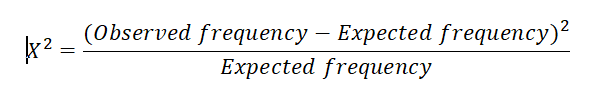

Observed frequency = No. of observations of class

Expected frequency = No. of expected observations of class if there was no relationship between the feature and the target.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import chi2

from sklearn.metrics import accuracy_score

In [3]:
titanic = sns.load_dataset('titanic')

In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
titanic.drop(['age','deck'],axis=1,inplace=True)

In [7]:
data = titanic[['sex','pclass','sibsp','parch','embarked','who','alone']]

Encode categorical variable.

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
labelencoder = LabelEncoder()

In [10]:
data['sex'] = labelencoder.fit_transform(data['sex'])

<ipython-input-10-0b4f2e223385>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sex'] = labelencoder.fit_transform(data['sex'])


In [11]:
data['embarked'] = labelencoder.fit_transform(data['embarked'])

<ipython-input-11-4c567ed9efa9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['embarked'] = labelencoder.fit_transform(data['embarked'])


In [12]:
data['who'] = labelencoder.fit_transform(data['who'])

<ipython-input-12-c948dc84977d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['who'] = labelencoder.fit_transform(data['who'])


In [13]:
data['alone'] = labelencoder.fit_transform(data['alone'])

<ipython-input-13-804d9df79edb>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['alone'] = labelencoder.fit_transform(data['alone'])


In [14]:
data

,sex,pclass,sibsp,parch,embarked,who,alone
0,1,3,1,0,2,1,0
1,0,1,1,0,0,2,0
2,0,3,0,0,2,2,1
3,0,1,1,0,2,2,0
4,1,3,0,0,2,1,1
...,...,...,...,...,...,...,...
886,1,2,0,0,2,1,1
887,0,1,0,0,2,2,1
888,0,3,1,2,2,2,0
889,1,1,0,0,0,1,1


In [15]:
x = data.copy()
y = titanic['survived']

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [17]:
f_score = chi2(x_train,y_train)

In [18]:
p_values = pd.Series(f_score[1],index=x_train.columns)

p_values.sort_values(ascending=True,inplace=True)

p-values will indicate the importance of each variable. the smaller the p-value the better it is.

In [19]:
p_values

sex         1.644805e-17
pclass      4.432215e-06
who         7.986579e-06
alone       2.197899e-03
parch       4.583534e-03
embarked    1.774336e-02
sibsp       4.940213e-02
dtype: float64

So sex column is the most important.

In [20]:
x_train_2 = x_train[['who','sex','pclass']]
x_test_2 = x_test[['who','sex','pclass']]

In [21]:
def random_forest_class(x_train,x_test,y_train,y_test):
    clf = RandomForestClassifier(n_estimators=100,random_state=0,n_jobs=-1)
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    print('accuracy score : ', accuracy_score(y_test,y_pred))

In [22]:
%%time
random_forest_class(x_train,x_test,y_train,y_test)

accuracy score :  0.8156424581005587
Wall time: 229 ms


In [23]:
%%time
random_forest_class(x_train_2,x_test_2,y_train,y_test)

accuracy score :  0.7932960893854749
Wall time: 385 ms


There is hardly any difference in accuracy.

This method comes handy when dealing with exceptionally large datasets or removing out unecessary columns that might hamper our 
accuracy score.